In [ ]:
#HW1
#part A
# 1--Model parameters such as logistic regression weights are chosen by the user before training--> False
# 2--Hyperparameters control the learning algorithm and must be set before calling fit().-->True
# 3--The split thresholds stored inside a fitted Decision Tree are hyperparameters.-->False
# 4--Setting C = 0.001 in LogisticRegression applies stronger regularisation than C = 10-->True
# 5--get_params() returns the coefficient values that the model learned from training data.-->False
# 6--GridSearchCV trains one model per hyperparameter combination per CV fold.-->True

In [1]:
#PART B
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
for clf in [LogisticRegression(), DecisionTreeClassifier(), KNeighborsClassifier()]:
    print(clf.__class__.__name__)
    print(clf.get_params())
    print()

LogisticRegression
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

DecisionTreeClassifier
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

KNeighborsClassifier
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}



In [ ]:
# 1--Name two Decision Tree hyperparameters that directly prevent overfitting
# max_depth
# min_samples_split

# 2--What does KNN weights do?
# Determines how neighbors vote.

# 3--Default max_depth?
# max_depth=None
# The tree keeps growing until stopping conditions are reached, which often leads to overfitting.

In [4]:
#HW2
import pandas as pd
from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("students_feature_engineered_v2_large.csv")

X = df.drop(columns=["Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])


param_dist = {
    "clf__n_estimators": randint(50, 300),
    "clf__max_depth": [3, 4, 5, 6, None],
    "clf__max_features": uniform(0.3, 0.7),
    "clf__min_samples_leaf": randint(1, 10),
}


random_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    refit=True
)


random_search.fit(X_train, y_train)


print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)


best_model = random_search.best_estimator_
print(best_model)

y_pred = best_model.predict(X_test)


test_accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(test_accuracy)


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


grid_combinations = 5 * 5 * 2 * 5


random_fits = 40 * 5

print("\nEquivalent Full Grid Fits:", grid_combinations)
print("RandomizedSearchCV Fits:", random_fits)

speedup = grid_combinations / random_fits

print(f"Speedup = {speedup:.2f}x")

Best Parameters:
{'clf__max_depth': 6, 'clf__max_features': np.float64(0.9655000144869412), 'clf__min_samples_leaf': 8, 'clf__n_estimators': 238}

Best Cross Validation Accuracy:
1.0
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(max_depth=6,
                                        max_features=np.float64(0.9655000144869412),
                                        min_samples_leaf=8, n_estimators=238,
                                        random_state=42))])

Test Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00       132

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Equivalent Full Grid Fits: 250
RandomizedSearchCV Fits: 200
Speedup = 1.25x


KFold k=3
Scores: [1. 1. 1.]
Mean Accuracy = 1.000
Std = 0.000
----------------------------------------
KFold k=5
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy = 1.000
Std = 0.000
----------------------------------------
KFold k=10
Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Accuracy = 1.000
Std = 0.000
----------------------------------------
StratifiedKFold k=5
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy = 1.000
Std = 0.000
----------------------------------------

Results Table
         Configuration   k Stratified  Mean Accuracy  Std
0            KFold k=3   3         No            1.0  0.0
1            KFold k=5   5         No            1.0  0.0
2           KFold k=10  10         No            1.0  0.0
3  StratifiedKFold k=5   5        Yes            1.0  0.0


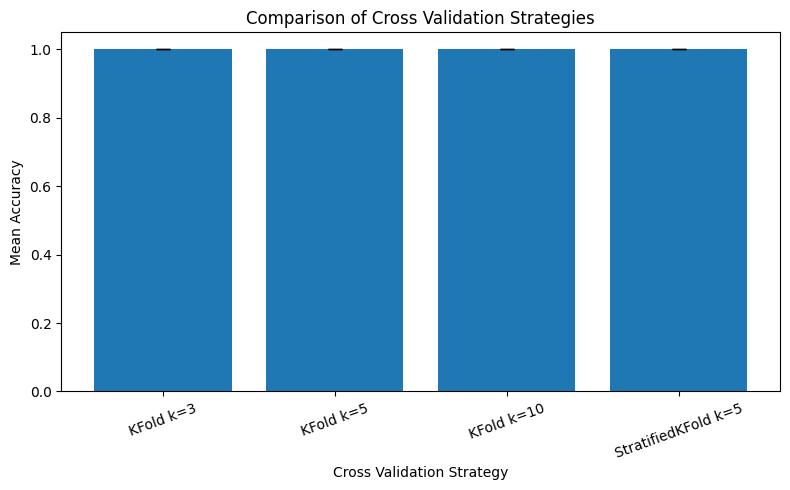


Chart saved as cv_comparison.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

df = pd.read_csv("students_feature_engineered_v2_large.csv")

X = df.drop(columns=["Pass"])
y = df["Pass"]


pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=42))
])


configs = [
    ("KFold k=3", KFold(n_splits=3, shuffle=True, random_state=42), "No", 3),
    ("KFold k=5", KFold(n_splits=5, shuffle=True, random_state=42), "No", 5),
    ("KFold k=10", KFold(n_splits=10, shuffle=True, random_state=42), "No", 10),
    ("StratifiedKFold k=5",
     StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
     "Yes",
     5)
]

results = []

for name, cv_obj, stratified, k in configs:

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv_obj,
        scoring="accuracy"
    )

    mean_score = scores.mean()
    std_score = scores.std()

    print(f"{name}")
    print("Scores:", scores)
    print(f"Mean Accuracy = {mean_score:.3f}")
    print(f"Std = {std_score:.3f}")
    print("-"*40)

    results.append({
        "Configuration": name,
        "k": k,
        "Stratified": stratified,
        "Mean Accuracy": mean_score,
        "Std": std_score
    })


results_df = pd.DataFrame(results)

print("\nResults Table")
print(results_df)


plt.figure(figsize=(8,5))

plt.bar(
    results_df["Configuration"],
    results_df["Mean Accuracy"],
    yerr=results_df["Std"],
    capsize=5
)

plt.xlabel("Cross Validation Strategy")
plt.ylabel("Mean Accuracy")
plt.title("Comparison of Cross Validation Strategies")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("cv_comparison.png")

plt.show()

print("\nChart saved as cv_comparison.png")

In [ ]:
# How does increasing k from 3 to 10 affect the mean and std?

# As k increases, each model is trained on a larger portion of the dataset and validated on a smaller portion. This generally 
# produces a more reliable estimate of model performance.
# The mean accuracy usually changes only slightly.
# The standard deviation often decreases, indicating more stable and consistent performance estimates across folds.



# Is there a practical cost to using k=10 instead of k=5?

# Yes
# Using 10-fold cross-validation requires training the model 10 times, whereas 5-fold cross-validation requires only 5 trainings.
# Therefore:
# Training takes approximately twice as long.
# Computational cost increases.
# The trade-off is that 10-fold CV often provides a slightly more reliable estimate of model performance.

In [6]:
#hw4
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import randint, uniform

wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = pd.Series(wine.target)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline_scores = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Baseline Accuracy")
print(f"{baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")

pipe_tree = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(max_depth=None,
                                   random_state=42))
])

cv = cross_validate(
    pipe_tree,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

train_acc = cv["train_score"].mean()
test_acc = cv["test_score"].mean()

print("\nDecision Tree")
print("Train:", train_acc)
print("Test :", test_acc)
print("Gap  :", train_acc-test_acc)


param_grid = {
    "clf__max_depth":[2,3,4,5],
    "clf__min_samples_split":[2,5,10],
    "clf__criterion":["gini","entropy"]
}

grid = GridSearchCV(
    pipe_tree,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print("\nGridSearch")
print(grid.best_params_)
print(grid.best_score_)


pipe_rf = Pipeline([
    ("scaler",StandardScaler()),
    ("clf",RandomForestClassifier(random_state=42))
])

param_dist={
    "clf__n_estimators":randint(50,300),
    "clf__max_depth":[3,4,5,6,None],
    "clf__max_features":uniform(0.3,0.7),
    "clf__min_samples_leaf":randint(1,10)
}

random_search=RandomizedSearchCV(
    pipe_rf,
    param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X_train,y_train)

print("\nRandom Search")
print(random_search.best_params_)
print(random_search.best_score_)


if grid.best_score_ > random_search.best_score_:
    best_model=grid.best_estimator_
    print("\nSelected: Decision Tree")
else:
    best_model=random_search.best_estimator_
    print("\nSelected: Random Forest")

y_pred=best_model.predict(X_test)

print("\nFinal Accuracy")
print(accuracy_score(y_test,y_pred))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


results=pd.DataFrame({
    "y_true":y_test,
    "y_pred":y_pred
})

results["correct"]=(results["y_true"]==results["y_pred"]).astype(int)

results.to_csv(
    "wine_predictions.csv",
    index=False
)

misclassified=(results["correct"]==0).sum()

print("\nMisclassified Samples:",misclassified)

Baseline Accuracy
0.993 ± 0.014

Decision Tree
Train: 1.0
Test : 0.916256157635468
Gap  : 0.08374384236453203

GridSearch
{'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_split': 2}
0.9231527093596059

Random Search
{'clf__max_depth': 5, 'clf__max_features': np.float64(0.3144091460070617), 'clf__min_samples_leaf': 2, 'clf__n_estimators': 137}
0.9862068965517242

Selected: Random Forest

Final Accuracy
1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion Matrix
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Misclassified Samples: 0


In [ ]:
#hw5
# Data leakage occurs when information from the validation or test data is accidentally used during the training process, 
# resulting in overly optimistic performance estimates. A Pipeline prevents data leakage by fitting preprocessing steps (such as scaling)
# only on the training portion of each cross-validation fold and then applying the same transformation to the validation data.

# The large difference between the cross-validation accuracy and the test accuracy suggests that the model has likely overfitted the
# training data or that data leakage occurred during preprocessing. To fix this, ensure that preprocessing is performed inside a Pipeline,
# avoid using the test set during model selection, and consider simplifying the model or collecting more representative data.

# GridSearchCV evaluates every possible hyperparameter combination, which becomes computationally expensive when there are many
# hyperparameters. With 20 hyperparameters and 5 values each, the number of combinations is enormous. RandomizedSearchCV samples
# only a fixed number of random combinations, making it much faster while still often finding near-optimal hyperparameters.

# Model parameters are values learned automatically from the training data during model fitting, whereas hyperparameters are values
# set by the user before training begins. In a Decision Tree, an example of a hyperparameter is max_depth, while examples of model
# parameters are the learned split thresholds and feature selections at each internal node of the tree.

# The test set should be used only once after the model has been completely trained and tuned because it represents unseen data.
# Using the test set repeatedly to adjust the model introduces data leakage and leads to overly optimistic performance estimates.
# Evaluating it only once provides an unbiased estimate of how the model will perform on new, real-world data.